# MLOps Lab 1 — EDA + Baseline (Telco Customer Churn)

**Що робимо в цьому ноутбуці:**
1) Завантаження даних та базові перевірки якості
2) Первинне очищення (мінімально необхідне для Telco)
3) EDA: пропуски, розподіли, зв’язки ознак із таргетом, кореляції числових
4) Baseline: простий пайплайн (preprocess + LogisticRegression) і метрики

**Важливо:** `data/` не комітиться — датасет має лежати у `data/raw/telco_churn.csv`.


In [1]:
from __future__ import annotations

import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# Базові налаштування відображення
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
def find_project_root() -> Path:
    """
    Надійно знаходить корінь проєкту навіть коли Jupyter стартує з PyCharm install dir.
    Ознака кореня: наявність папки src/ і (main.py або requirements.txt).
    """

    def is_root(p: Path) -> bool:
        return (p / "src").exists() and ((p / "main.py").exists() or (p / "requirements.txt").exists())

    # 1) якщо захочеш — можна виставити змінну середовища PROJECT_ROOT
    env_root = os.environ.get("PROJECT_ROOT")
    if env_root:
        p = Path(env_root).expanduser().resolve()
        if is_root(p):
            return p

    # 2) кандидати (швидко і практично) — під твою реальну структуру
    candidates = [
        Path.home() / "8 semester" / "MLOps",
        Path(r"C:\Users\Admin\8 semester\MLOps"),
        Path.cwd(),
    ]

    for c in candidates:
        try:
            p = c.resolve()
        except Exception:
            continue

        # перевірка самого кандидата
        if is_root(p):
            return p

        # піднімаємось вгору від кандидата (на випадок якщо cwd = notebooks/)
        q = p
        for _ in range(12):
            if is_root(q):
                return q
            if q.parent == q:
                break
            q = q.parent

    # 3) fallback: підйом від cwd
    q = Path.cwd().resolve()
    for _ in range(20):
        if is_root(q):
            return q
        if q.parent == q:
            break
        q = q.parent

    raise RuntimeError(
        "Не зміг знайти корінь проєкту. "
        "Перевір, що в корені є src/ та main.py (або requirements.txt)."
    )

ROOT = find_project_root()
os.chdir(ROOT)  # важливо: після цього всі відносні шляхи працюють як очікується

DATA_PATH = ROOT / "data" / "raw" / "telco_churn.csv"

print("ROOT:", ROOT)
print("CWD :", Path.cwd())
print("DATA_PATH exists:", DATA_PATH.exists())

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Не знайшов датасет: {DATA_PATH}\n"
        "Переконайся, що файл лежить саме тут: data/raw/telco_churn.csv"
    )

ROOT: C:\Users\Admin\8 semester\MLOps
CWD : C:\Users\Admin\8 semester\MLOps
DATA_PATH exists: True


In [3]:
df_raw = pd.read_csv(DATA_PATH)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


1) Швидкий профіль датасету (типи, пропуски, дублі)

Тут ми робимо базові перевірки, щоб зрозуміти, що чистити та що може ламати навчання.

In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_ratio = (missing / len(df_raw)).sort_values(ascending=False)

summary_missing = pd.DataFrame(
    {"missing_count": missing, "missing_ratio": missing_ratio}
).query("missing_count > 0")

summary_missing.head(20)

,missing_count,missing_ratio


In [6]:
dup_count = df_raw.duplicated().sum()
print("Duplicated rows:", dup_count)

Duplicated rows: 0


2) Мінімальне очищення Telco (перед EDA та baseline)

Типові моменти Telco:
- `customerID` — ідентифікатор (для моделі не потрібен)
- `TotalCharges` часто приходить як string з пробілами → переводимо в numeric (`NaN`, якщо не вийшло)
- Таргет `Churn`: `Yes/No` → `1/0`

In [7]:
TARGET_COL = "Churn"
ID_COL = "customerID"

def clean_telco(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # прибираємо ID
    if ID_COL in df.columns:
        df = df.drop(columns=[ID_COL])

    # TotalCharges -> numeric
    if "TotalCharges" in df.columns:
        # інколи там бувають пробіли або порожні рядки
        df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    # приберемо рядки без таргету (дуже рідко, але краще явно)
    if TARGET_COL in df.columns:
        df = df.dropna(subset=[TARGET_COL])

    return df


df = clean_telco(df_raw)

print("After clean shape:", df.shape)
df.head()

After clean shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
# Перевірка таргету
if TARGET_COL not in df.columns:
    raise ValueError(f"Не знайшов таргет '{TARGET_COL}' у колонках: {list(df.columns)}")

print(df[TARGET_COL].value_counts(dropna=False))
print(df[TARGET_COL].value_counts(normalize=True, dropna=False))

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [9]:
# Мапимо таргет у 0/1 для baseline
y = df[TARGET_COL].map({"Yes": 1, "No": 0})
if y.isna().any():
    bad_vals = df.loc[y.isna(), TARGET_COL].unique()
    raise ValueError(f"Неочікувані значення в таргеті {TARGET_COL}: {bad_vals}")

X = df.drop(columns=[TARGET_COL])

print("X shape:", X.shape, "y mean (churn rate):", y.mean().round(4))

X shape: (7043, 19) y mean (churn rate): 0.2654


3) EDA: розподіл таргету + базові графіки

Тут робимо графіки “вплив ознак на churn” на інтуїтивному рівні.

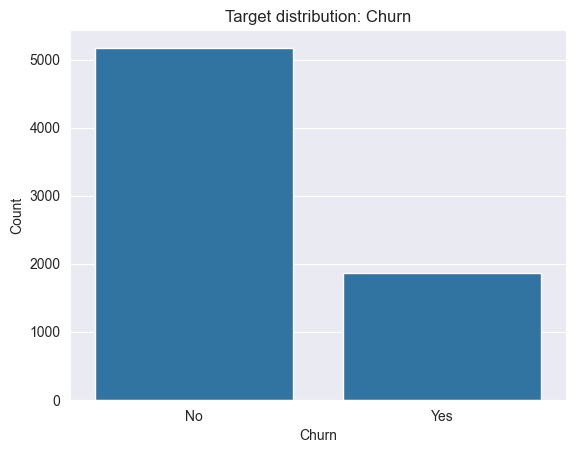

In [10]:
plt.figure()
ax = sns.countplot(x=df[TARGET_COL])
ax.set_title("Target distribution: Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Count")
plt.show()

In [11]:
# Розділимо ознаки на числові/категоріальні
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("Numeric:", len(numeric_cols), numeric_cols)
print("Categorical:", len(categorical_cols), categorical_cols[:20], "..." if len(categorical_cols) > 20 else "")

Numeric: 4 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: 15 ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'] 


In [12]:
# Пропуски після чистки
missing2 = X.isna().sum().sort_values(ascending=False)
missing2 = missing2[missing2 > 0]
missing2.head(20)

TotalCharges    11
dtype: int64

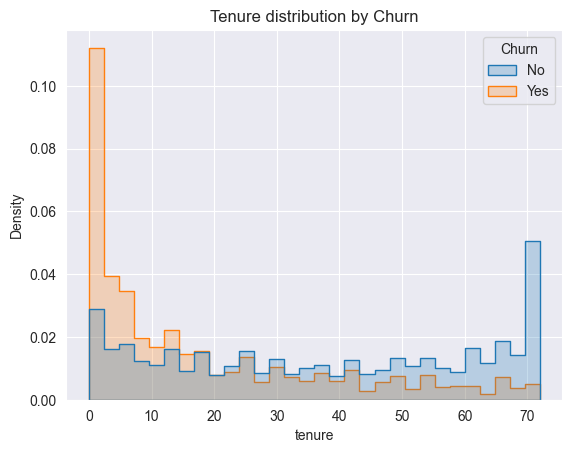

In [13]:
# Розподіл tenure (якщо є) по класах churn
if "tenure" in df.columns:
    plt.figure()
    ax = sns.histplot(data=df, x="tenure", hue=TARGET_COL, bins=30, element="step", stat="density", common_norm=False)
    ax.set_title("Tenure distribution by Churn")
    plt.show()

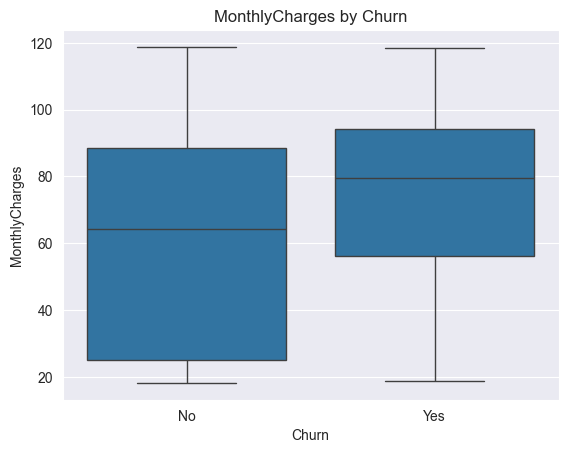

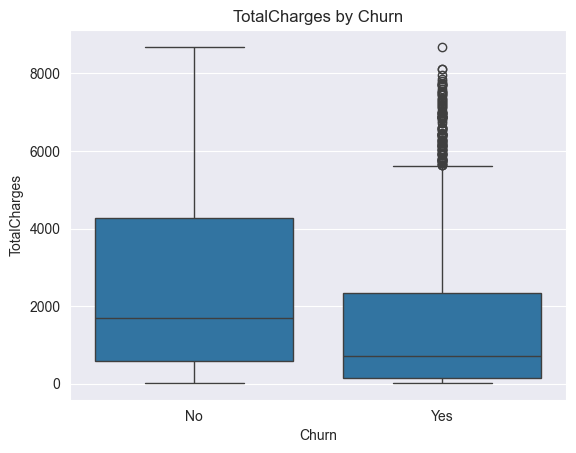

In [14]:
# MonthlyCharges / TotalCharges по churn
for col in ["MonthlyCharges", "TotalCharges"]:
    if col in df.columns:
        plt.figure()
        ax = sns.boxplot(data=df, x=TARGET_COL, y=col)
        ax.set_title(f"{col} by Churn")
        plt.show()

4) EDA: категоріальні ознаки (частоти)

Для Telco багато категоріальних фіч. Ми не будемо малювати 30 графіків — зробимо “топові”:
- обираємо кілька колонок з найменшою кількістю унікальних значень
- дивимось, як змінюється churn rate в групах

In [15]:
def churn_rate_by_category(df: pd.DataFrame, col: str) -> pd.DataFrame:
    tmp = df[[col, TARGET_COL]].copy()
    tmp["churn_bin"] = tmp[TARGET_COL].map({"Yes": 1, "No": 0})
    g = tmp.groupby(col)["churn_bin"].agg(["mean", "count"]).reset_index()
    g = g.sort_values(["mean", "count"], ascending=[False, False])
    g.rename(columns={"mean": "churn_rate", "count": "n"}, inplace=True)
    return g

# виберемо кілька “компактних” категоріальних
cat_uniques = [(c, df[c].nunique(dropna=False)) for c in categorical_cols]
cat_uniques_sorted = sorted(cat_uniques, key=lambda x: x[1])
top_cat = [c for c, k in cat_uniques_sorted[:6]]  # 6 штук достатньо

top_cat, cat_uniques_sorted[:10]

(['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'PaperlessBilling',
  'MultipleLines'],
 [('gender', 2),
  ('Partner', 2),
  ('Dependents', 2),
  ('PhoneService', 2),
  ('PaperlessBilling', 2),
  ('MultipleLines', 3),
  ('InternetService', 3),
  ('OnlineSecurity', 3),
  ('OnlineBackup', 3),
  ('DeviceProtection', 3)])

,gender,churn_rate,n
0,Female,0.269209,3488
1,Male,0.261603,3555


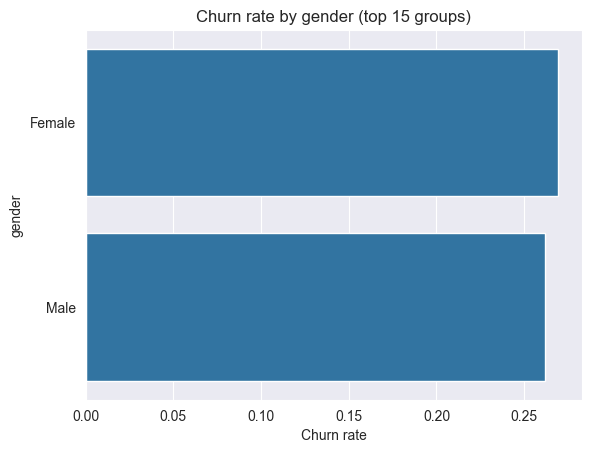

,Partner,churn_rate,n
0,No,0.329580,3641
1,Yes,0.196649,3402


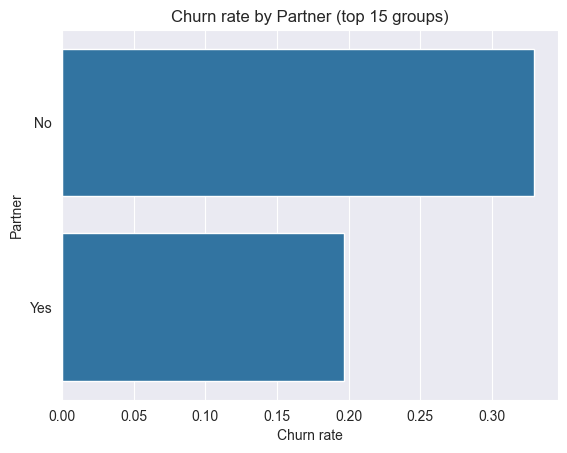

,Dependents,churn_rate,n
0,No,0.312791,4933
1,Yes,0.154502,2110


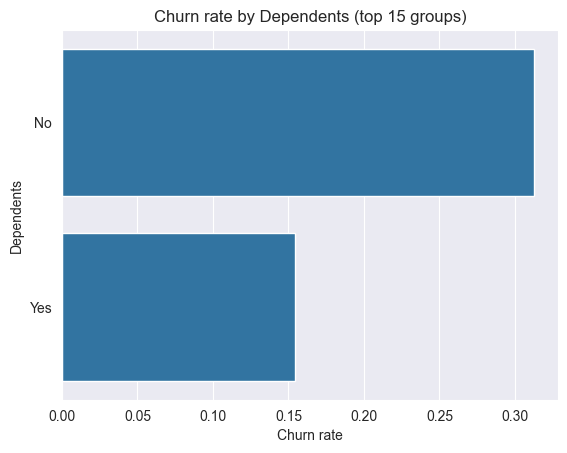

,PhoneService,churn_rate,n
1,Yes,0.267096,6361
0,No,0.249267,682


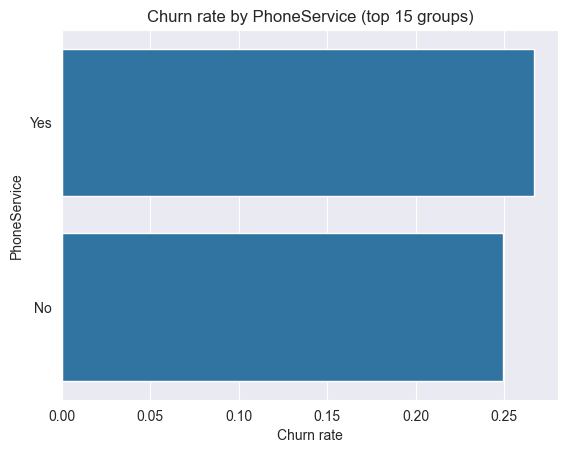

,PaperlessBilling,churn_rate,n
1,Yes,0.335651,4171
0,No,0.163301,2872


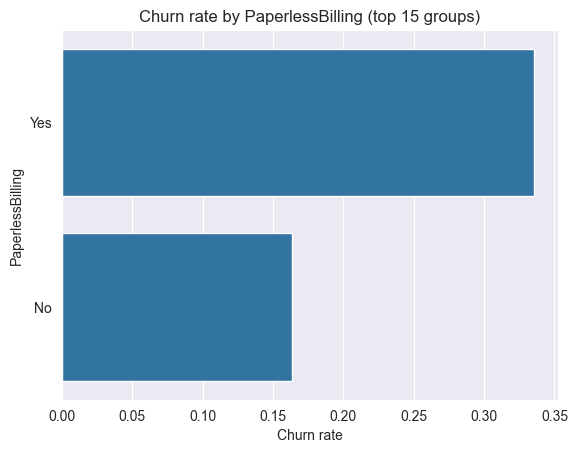

,MultipleLines,churn_rate,n
2,Yes,0.286099,2971
0,No,0.250442,3390
1,No phone service,0.249267,682


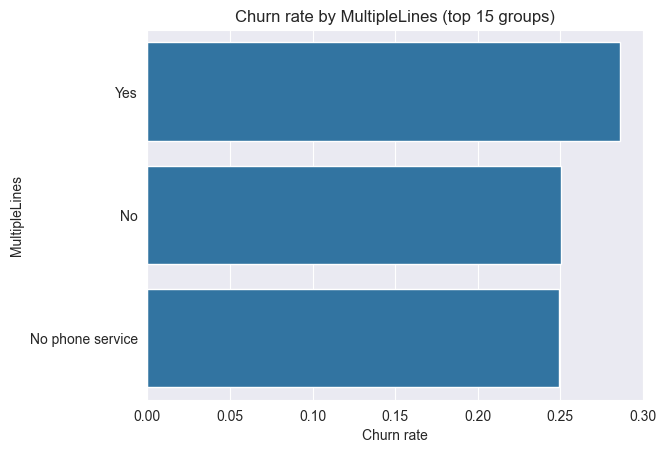

In [16]:
for col in top_cat:
    tbl = churn_rate_by_category(df, col)
    display(tbl.head(15))

    plt.figure()
    ax = sns.barplot(data=tbl.head(15), x="churn_rate", y=col)
    ax.set_title(f"Churn rate by {col} (top 15 groups)")
    ax.set_xlabel("Churn rate")
    ax.set_ylabel(col)
    plt.show()

5) Кореляції (для числових)

Кореляція “як є” працює тільки для числових ознак. Додаємо таргет як 0/1 і дивимось heatmap.

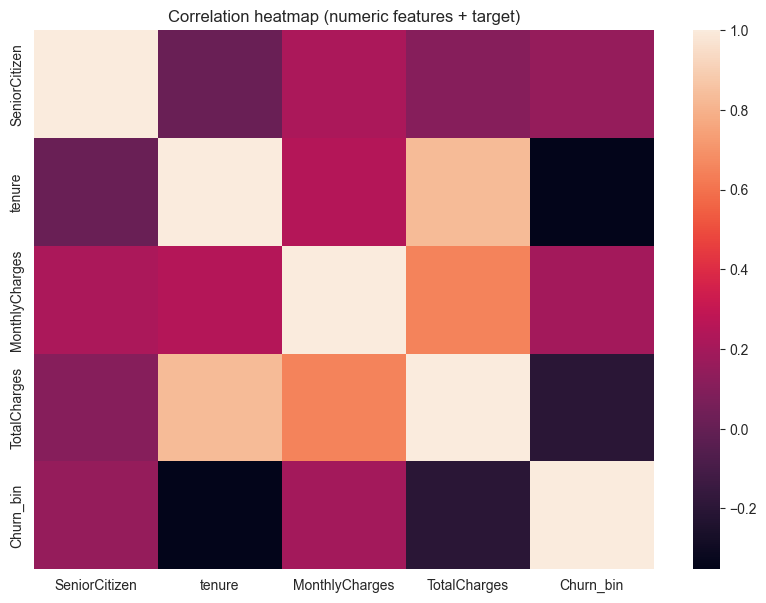

In [17]:
corr_df = df[numeric_cols].copy()
corr_df["Churn_bin"] = y

if len(numeric_cols) > 0:
    corr = corr_df.corr(numeric_only=True)

    plt.figure(figsize=(10, 7))
    ax = sns.heatmap(corr, annot=False)
    ax.set_title("Correlation heatmap (numeric features + target)")
    plt.show()

In [18]:
# Топ кореляцій із таргетом (як підказка, не “істина”)
if len(numeric_cols) > 0:
    corr_target = corr["Churn_bin"].drop("Churn_bin").sort_values(ascending=False)
    print("Top positive correlation with churn:")
    display(corr_target.head(10))

    print("Top negative correlation with churn:")
    display(corr_target.tail(10))

Top positive correlation with churn:


MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn_bin, dtype: float64

Top negative correlation with churn:


MonthlyCharges    0.193356
SeniorCitizen     0.150889
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn_bin, dtype: float64

6) Baseline модель (Pipeline + LogisticRegression)

Тут ми робимо саме baseline, який:
- обробляє пропуски
- кодує категоріальні (OneHot)
- масштабує числові
- дає метрики (train/test)

Це і є “мінімально необхідна” модель для ЛР1.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols),
])

baseline_model = LogisticRegression(
    solver="liblinear",
    max_iter=2000,
    random_state=42,
)

baseline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", baseline_model),
])

baseline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [20]:
baseline.fit(X_train, y_train)

def eval_binary(model, X_tr, y_tr, X_te, y_te):
    pred_tr = model.predict(X_tr)
    pred_te = model.predict(X_te)

    proba_tr = model.predict_proba(X_tr)[:, 1] if hasattr(model, "predict_proba") else None
    proba_te = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None

    def pack(y_true, y_pred, y_proba):
        out = {
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
        }
        if y_proba is not None:
            out["roc_auc"] = roc_auc_score(y_true, y_proba)
        return out

    return pack(y_tr, pred_tr, proba_tr), pack(y_te, pred_te, proba_te), pred_te

m_train, m_test, y_pred_test = eval_binary(baseline, X_train, y_train, X_test, y_test)

print("Train metrics:", {k: round(v, 4) for k, v in m_train.items()})
print("Test  metrics:", {k: round(v, 4) for k, v in m_test.items()})

Train metrics: {'accuracy': 0.8058, 'precision': 0.6613, 'recall': 0.5498, 'f1': 0.6004, 'roc_auc': 0.8493}
Test  metrics: {'accuracy': 0.8055, 'precision': 0.6572, 'recall': 0.5588, 'f1': 0.604, 'roc_auc': 0.8419}


In [21]:
print("Classification report (test):")
print(classification_report(y_test, y_pred_test, digits=4, zero_division=0))

Classification report (test):
              precision    recall  f1-score   support

           0     0.8488    0.8947    0.8711      1035
           1     0.6572    0.5588    0.6040       374

    accuracy                         0.8055      1409
   macro avg     0.7530    0.7268    0.7376      1409
weighted avg     0.7979    0.8055    0.8002      1409



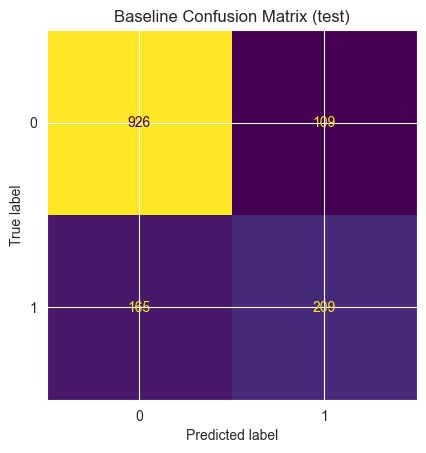

In [22]:
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots()
disp.plot(ax=ax, colorbar=False, values_format="d")
ax.set_title("Baseline Confusion Matrix (test)")
plt.show()

7) Короткі висновки (для звіту)

Можеш залишити ці пункти як основу тексту у звіті:
- класова пропорція churn (незбалансованість)
- TotalCharges потребує приведення до numeric (частина значень стає NaN)
- деякі ознаки мають очевидний зв’язок із churn (тенденції по tenure/charges/контрактах)
- baseline дає стартові метрики, від яких потім можна покращуватись через експерименти в MLflow